# Stage 3: Designing the Integrated Heating + Cooling System

This notebook builds and evaluates the heart of our submission: a single system that
both **heats and cools** a city district from the same geothermal wells. The setup pairs
a *geothermal doublet* (one well pumps warm groundwater up, a second pushes the cooled
water back down) with a **heat pump**, **seasonal underground heat storage** (HT-ATES —
High-Temperature Aquifer Thermal Energy Storage, where summer heat is banked underground
and recovered in winter), and a **heat-driven chiller** that turns spare summer heat into
air-conditioning. The key idea we test here: serving *both* heating and cooling keeps the
expensive wells busy year-round, which spreads their fixed cost over far more delivered
energy and lowers the price per unit of energy (the LCoE — Levelised Cost of Energy).

**How to run:** Run the cells top to bottom. The first code cell imports the project's
`geothermal` package and runs the system simulation; later cells print the headline
numbers and draw the two figures. Everything is computed from the model in `src/geothermal`.

## Setup and simulation

We import the analysis tools and immediately run the model. `district_demand()` gives the
month-by-month heating and cooling the district needs; `SystemDesign()` is our chosen build
(two doublets sized for 10 MW of geothermal heat plus a heat pump); and `simulate()` dispatches
that hardware against the demand. The result `perf` holds annual totals, and `perf.monthly`
(`m`) holds the monthly breakdown we plot later. *No output is expected here* — it just sets
everything up. (MW = megawatts of power; "th" denotes thermal/heat as opposed to electricity.)

In [1]:
from __future__ import annotations

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from geothermal import config
from geothermal.design import SystemDesign, district_demand, simulate

FIG_DIR = config.OUTPUTS_DIR / "figures" / "phase3"
FIG_DIR.mkdir(parents=True, exist_ok=True)

demand = district_demand()
design = SystemDesign()  # 2-doublet programme: 10 MW geothermal + heat pump
perf = simulate(design, demand)
m = perf.monthly

## Section 1: Capacities and annual energy

Here we print the system's headline numbers: how much heating and cooling it can deliver,
the yearly energy totals, and how much of the cooling comes "for free" from heat rather than
electricity. Look for the **heating capacity near the 10 MW target**, the GWh/yr (gigawatt-hours
per year) of heat and cool delivered, and the share of cooling supplied by the **absorption
chiller** — a device that makes cold using heat instead of a power-hungry compressor.

In [2]:
print("=" * 78)
print("SECTION 1 — INTEGRATED SYSTEM (2 doublets, 10 MW geothermal + heat pump)")
print("=" * 78)
print(f"  heating capacity (geo + heat pump): {perf.heating_capacity_mw:.1f} MWth  (target 10)")
print("  cooling: absorption chiller on spare summer geothermal + free cooling + backup")
print(f"  heat delivered : {perf.heat_delivered_gj / 3600:5.0f} GWh/yr")
print(f"  cool delivered : {perf.cool_delivered_gj / 3600:5.0f} GWh/yr "
      f"({perf.absorption_cool_gj / perf.cool_delivered_gj * 100:.0f}% from heat-driven absorption)")
print(f"  heat-pump power: {perf.heat_pump_mwh_e / 1000:5.1f} GWh_e/yr")
print(f"  backup heat    : {perf.backup_heat_gj / 3600:5.1f} GWh/yr")

SECTION 1 — INTEGRATED SYSTEM (2 doublets, 10 MW geothermal + heat pump)
  heating capacity (geo + heat pump): 12.9 MWth  (target 10)
  cooling: absorption chiller on spare summer geothermal + free cooling + backup
  heat delivered :    45 GWh/yr
  cool delivered :    12 GWh/yr (100% from heat-driven absorption)
  heat-pump power:   9.9 GWh_e/yr
  backup heat    :   0.0 GWh/yr


## Section 2: Why heating + cooling together is cheaper

This is the central argument of the design. The **capacity factor** is the fraction of the
year the wells actually do useful work (100% would mean flat-out, all year). Wells sized for
winter heating sit largely idle in summer. By using that idle summer capacity to drive cooling,
we raise the capacity factor. Look for the **two percentages** and the **uplift** between them:
more useful output from the *same* wells means the fixed drilling cost is spread thinner, so the
cost per unit of energy drops.

In [3]:
print("\n" + "=" * 78)
print("SECTION 2 — WHY HEATING + COOLING TOGETHER IS CHEAPER")
print("=" * 78)
cf_h = perf.geo_capacity_factor_heating_only
cf_b = perf.geo_capacity_factor
print(f"  geothermal capacity factor, heating only      : {cf_h * 100:.0f}%")
print(f"  geothermal capacity factor, heating + cooling : {cf_b * 100:.0f}%")
print(f"  → {(cf_b / cf_h - 1) * 100:.0f}% more useful output from the SAME wells,")
print("    so the fixed well cost is spread over more delivered energy → lower LCoE.")


SECTION 2 — WHY HEATING + COOLING TOGETHER IS CHEAPER
  geothermal capacity factor, heating only      : 40%
  geothermal capacity factor, heating + cooling : 60%
  → 51% more useful output from the SAME wells,
    so the fixed well cost is spread over more delivered energy → lower LCoE.


## Figure 1 - Monthly dispatch (heating and cooling)

This pair of stacked-bar charts shows, month by month, *which* piece of equipment meets demand.
The top panel covers **heating** (geothermal + heat pump, stored heat released from HT-ATES, and
a small gas/electric **backup** for the coldest peaks); the bottom covers **cooling** (the
heat-driven absorption chiller, "free cooling" drawn from the cold side of storage, and a
conventional **compression chiller** as top-up). The dashed line is actual demand. Look for the
stacked bars tracking the demand line, with geothermal carrying most of the load in both seasons.

In [4]:
months = np.arange(1, 13)
fig, (axh, axc) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

geohp = m["geo_heat_mw"].to_numpy() + m["hp_elec_mw"].to_numpy()  # delivered by geo+HP
axh.bar(months, geohp, label="geothermal + heat pump", color="tab:red")
axh.bar(months, m["ates_discharge_mw"], bottom=geohp, label="HT-ATES discharge", color="tab:orange")
axh.bar(months, m["backup_mw"], bottom=geohp + m["ates_discharge_mw"].to_numpy(),
        label="backup", color="tab:gray")
axh.plot(months, m["heating_mw"], "k--o", ms=4, label="heating demand")
axh.set_ylabel("Heating (MWth)")
axh.set_title("Monthly heating dispatch")
axh.legend(fontsize=8, ncol=2)

axc.bar(months, m["abs_cool_mw"], label="absorption (geothermal-driven)", color="tab:blue")
axc.bar(months, m["free_cool_mw"], bottom=m["abs_cool_mw"], label="free cooling (ATES)", color="tab:cyan")
axc.bar(months, m["comp_cool_mw"], bottom=m["abs_cool_mw"].to_numpy() + m["free_cool_mw"].to_numpy(),
        label="compression chiller", color="tab:gray")
axc.plot(months, m["cooling_mw"], "k--o", ms=4, label="cooling demand")
axc.set_ylabel("Cooling (MWth)")
axc.set_xlabel("Month")
axc.set_title("Monthly cooling dispatch")
axc.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_dispatch.png", dpi=130)

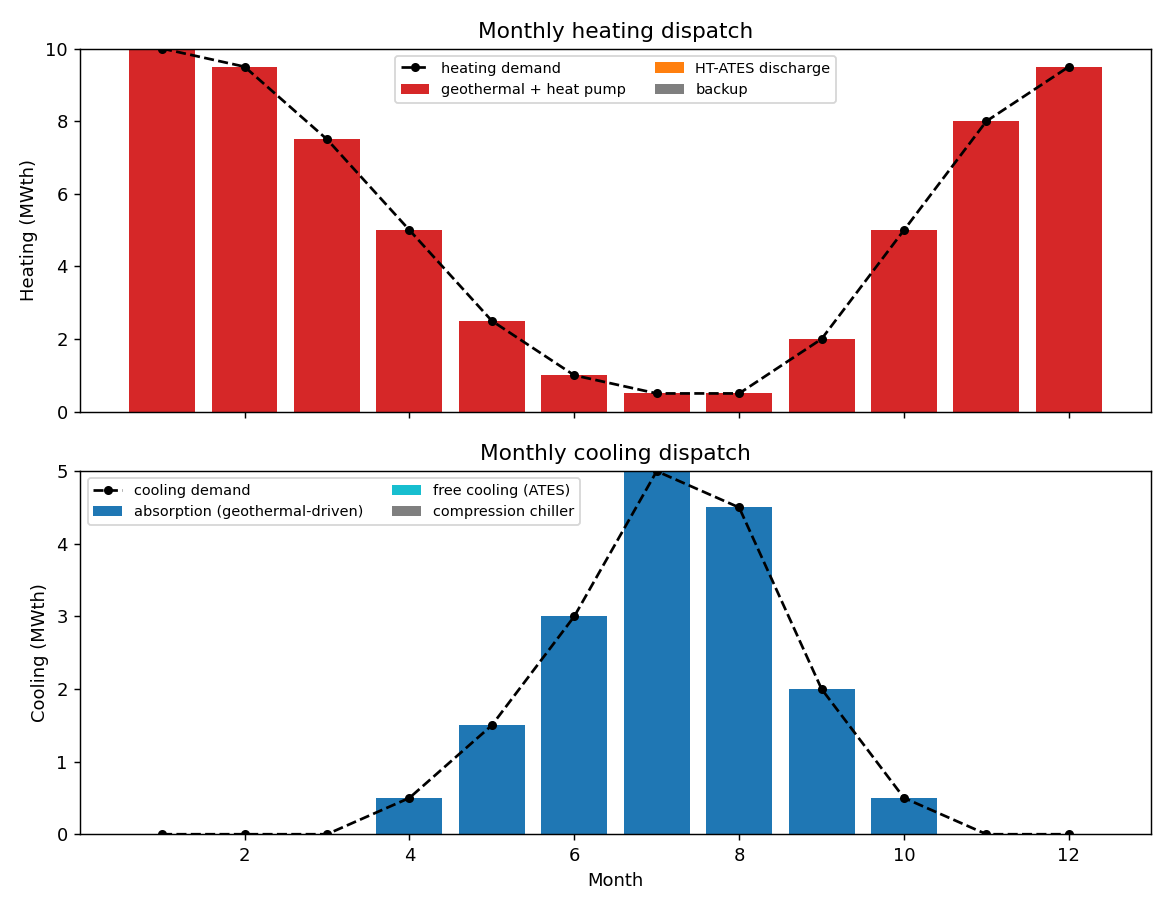

In [5]:
from IPython.display import Image

Image(filename=str(FIG_DIR / "monthly_dispatch.png"))

## Figure 2 — Capacity-factor uplift

A simple side-by-side bar chart making the Section 2 result visual: the geothermal capacity factor
with heating alone versus heating **plus** cooling. The taller green bar is the payoff — cooling
puts otherwise-idle wells to work, which is what brings the cost down.

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["heating\nonly", "heating +\ncooling"], [cf_h * 100, cf_b * 100],
       color=["tab:gray", "tab:green"])
ax.set_ylabel("Geothermal capacity factor (%)")
ax.set_title("Cooling monetises idle geothermal capacity")
for i, v in enumerate([cf_h * 100, cf_b * 100]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "capacity_factor_uplift.png", dpi=130)

print(f"\nFigures written to {FIG_DIR}")


Figures written to /Users/vadmin/Documents/Lab/Projects/DSEATS/June26GeoDatathon/outputs/figures/phase3


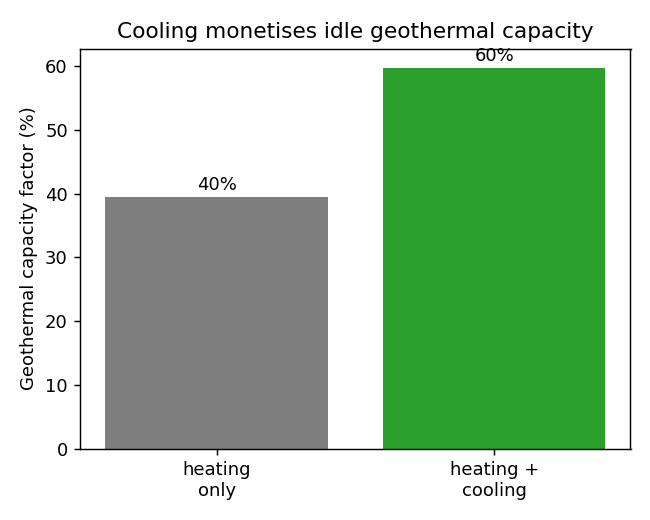

In [7]:
Image(filename=str(FIG_DIR / "capacity_factor_uplift.png"))